<a href="https://colab.research.google.com/github/Darshkutal/AI-Projects/blob/main/nfl_analysis_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NFL Player Performance Prediction Model
## Research Paper Implementation - Interactive Analysis

This notebook provides an interactive environment to explore the NFL prediction model comparing:
- **Baseline**: Multiple Linear Regression
- **ML Model 1**: Random Forest
- **ML Model 2**: XGBoost (Gradient Boosting)

---

## 1. Setup and Imports

In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from nfl_prediction_model import NFLPredictionModel

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 2)

print("✓ Setup complete!")

ModuleNotFoundError: No module named 'nfl_prediction_model'

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')


class NFLPredictionModel:
    """
    Main class for NFL player performance prediction.
    Implements multiple models and evaluation metrics.
    """

    def __init__(self, data_path=None):
        """
        Initialize the prediction model.

        Parameters:
        -----------
        data_path : str, optional
            Path to historical NFL data (2019-2023)
        """
        self.data_path = data_path
        self.models = {}
        self.results = {}
        self.scaler = StandardScaler()
        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None

    def load_and_prepare_data(self, df=None):
        """
        Load and prepare NFL player data for modeling.

        Parameters:
        -----------
        df : pandas.DataFrame, optional
            Pre-loaded dataframe with NFL player statistics

        Returns:
        --------
        X : pandas.DataFrame
            Feature matrix
        y : pandas.Series
            Target variable
        """
        if df is None and self.data_path:
            df = pd.read_csv(self.data_path)
        elif df is None:
            # Generate synthetic data for demonstration
            df = self._generate_synthetic_data()

        # Feature engineering
        df = self._engineer_features(df)

        # Separate features and target
        target_col = 'target_performance'  # e.g., passing_yards, receptions, etc.
        feature_cols = [col for col in df.columns if col != target_col]

        X = df[feature_cols]
        y = df[target_col]

        return X, y

    def _generate_synthetic_data(self, n_samples=5000):
        """
        Generate synthetic NFL player data for demonstration.
        Simulates 2019-2023 seasons with realistic patterns.

        Parameters:
        -----------
        n_samples : int
            Number of player-game observations to generate

        Returns:
        --------
        df : pandas.DataFrame
            Synthetic NFL player statistics
        """
        np.random.seed(42)

        # Player positions
        positions = ['QB', 'RB', 'WR', 'TE']
        position_weights = [0.15, 0.30, 0.40, 0.15]

        data = {
            # Historical performance metrics
            'avg_previous_4_games': np.random.normal(250, 80, n_samples),
            'avg_season_performance': np.random.normal(240, 75, n_samples),
            'avg_last_season': np.random.normal(235, 70, n_samples),
            'avg_vs_opponent': np.random.normal(245, 85, n_samples),

            # Contextual factors
            'home_game': np.random.choice([0, 1], n_samples, p=[0.5, 0.5]),
            'temperature': np.random.normal(65, 15, n_samples),
            'wind_speed': np.random.gamma(2, 3, n_samples),
            'precipitation': np.random.choice([0, 1], n_samples, p=[0.75, 0.25]),

            # Team and opponent factors
            'team_offensive_rank': np.random.randint(1, 33, n_samples),
            'opponent_defensive_rank': np.random.randint(1, 33, n_samples),
            'vegas_team_spread': np.random.normal(0, 7, n_samples),
            'vegas_over_under': np.random.normal(47, 5, n_samples),

            # Player-specific
            'position': np.random.choice(positions, n_samples, p=position_weights),
            'years_experience': np.random.randint(1, 16, n_samples),
            'injury_designation': np.random.choice([0, 1], n_samples, p=[0.85, 0.15]),
            'snap_share_last_game': np.random.beta(8, 2, n_samples) * 100,

            # Recent trend
            'trending_up': np.random.choice([0, 1], n_samples, p=[0.6, 0.4]),
            'days_rest': np.random.choice([6, 7, 8, 9, 10], n_samples),
        }

        df = pd.DataFrame(data)

        # Generate target variable with realistic relationships
        target = (
            0.35 * df['avg_previous_4_games'] +
            0.25 * df['avg_season_performance'] +
            0.15 * df['avg_vs_opponent'] +
            10 * df['home_game'] +
            -2 * df['opponent_defensive_rank'] +
            1.5 * df['vegas_team_spread'] +
            5 * df['trending_up'] +
            -15 * df['injury_designation'] +
            0.3 * df['snap_share_last_game'] +
            np.random.normal(0, 35, n_samples)  # Random noise
        )

        # Ensure realistic bounds
        df['target_performance'] = np.clip(target, 0, 500)

        return df

    def _engineer_features(self, df):
        """
        Engineer additional features from raw data.

        Parameters:
        -----------
        df : pandas.DataFrame
            Raw NFL player data

        Returns:
        --------
        df : pandas.DataFrame
            Data with engineered features
        """
        # One-hot encode position
        if 'position' in df.columns:
            df = pd.get_dummies(df, columns=['position'], prefix='pos')

        # Interaction features
        if 'avg_previous_4_games' in df.columns and 'trending_up' in df.columns:
            df['momentum'] = df['avg_previous_4_games'] * df['trending_up']

        if 'opponent_defensive_rank' in df.columns and 'avg_season_performance' in df.columns:
            df['matchup_difficulty'] = df['opponent_defensive_rank'] / (df['avg_season_performance'] + 1)

        if 'home_game' in df.columns and 'vegas_team_spread' in df.columns:
            df['home_favorite'] = df['home_game'] * (df['vegas_team_spread'] > 0).astype(int)

        # Weather impact
        if 'temperature' in df.columns and 'wind_speed' in df.columns:
            df['weather_severity'] = (abs(df['temperature'] - 65) / 10) + (df['wind_speed'] / 5)

        return df

    def prepare_train_test_split(self, X, y, test_size=0.2, random_state=42):
        """
        Split data into training and testing sets.

        Parameters:
        -----------
        X : pandas.DataFrame
            Feature matrix
        y : pandas.Series
            Target variable
        test_size : float
            Proportion of data for testing
        random_state : int
            Random seed for reproducibility
        """
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            X, y, test_size=test_size, random_state=random_state
        )

        # Scale features
        self.X_train_scaled = self.scaler.fit_transform(self.X_train)
        self.X_test_scaled = self.scaler.transform(self.X_test)

    def train_baseline_model(self):
        """
        Train traditional Multiple Linear Regression baseline.
        """
        print("Training Baseline Model (Multiple Linear Regression)...")

        model = LinearRegression()
        model.fit(self.X_train_scaled, self.y_train)

        self.models['Linear Regression'] = model

        # Predictions
        train_pred = model.predict(self.X_train_scaled)
        test_pred = model.predict(self.X_test_scaled)

        # Store results
        self.results['Linear Regression'] = {
            'train_pred': train_pred,
            'test_pred': test_pred,
            'model': model
        }

        print("✓ Baseline model trained successfully")

    def train_random_forest(self, n_estimators=100, max_depth=None, random_state=42):
        """
        Train Random Forest model.

        Parameters:
        -----------
        n_estimators : int
            Number of trees in the forest
        max_depth : int
            Maximum depth of trees
        random_state : int
            Random seed
        """
        print("Training Random Forest model...")

        model = RandomForestRegressor(
            n_estimators=n_estimators,
            max_depth=max_depth,
            random_state=random_state,
            n_jobs=-1
        )
        model.fit(self.X_train, self.y_train)

        self.models['Random Forest'] = model

        # Predictions
        train_pred = model.predict(self.X_train)
        test_pred = model.predict(self.X_test)

        # Store results
        self.results['Random Forest'] = {
            'train_pred': train_pred,
            'test_pred': test_pred,
            'model': model
        }

        print("✓ Random Forest trained successfully")

    def train_xgboost(self, n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42):
        """
        Train XGBoost (Gradient Boosting Machine) model.

        Parameters:
        -----------
        n_estimators : int
            Number of boosting rounds
        learning_rate : float
            Step size shrinkage
        max_depth : int
            Maximum tree depth
        random_state : int
            Random seed
        """
        print("Training XGBoost model...")

        model = XGBRegressor(
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            max_depth=max_depth,
            random_state=random_state,
            n_jobs=-1
        )
        model.fit(self.X_train, self.y_train)

        self.models['XGBoost'] = model

        # Predictions
        train_pred = model.predict(self.X_train)
        test_pred = model.predict(self.X_test)

        # Store results
        self.results['XGBoost'] = {
            'train_pred': train_pred,
            'test_pred': test_pred,
            'model': model
        }

        print("✓ XGBoost trained successfully")

    def evaluate_models(self):
        """
        Evaluate all trained models using multiple metrics.

        Returns:
        --------
        evaluation_df : pandas.DataFrame
            Comparison of model performance metrics
        """
        print("\n" + "="*60)
        print("MODEL EVALUATION RESULTS")
        print("="*60 + "\n")

        evaluation_results = []

        for model_name, results in self.results.items():
            test_pred = results['test_pred']

            # Calculate metrics
            mae = mean_absolute_error(self.y_test, test_pred)
            rmse = np.sqrt(mean_squared_error(self.y_test, test_pred))
            r2 = r2_score(self.y_test, test_pred)

            # Mean Absolute Percentage Error
            mape = np.mean(np.abs((self.y_test - test_pred) / self.y_test)) * 100

            evaluation_results.append({
                'Model': model_name,
                'MAE': mae,
                'RMSE': rmse,
                'R²': r2,
                'MAPE (%)': mape
            })

            print(f"{model_name}:")
            print(f"  Mean Absolute Error (MAE): {mae:.2f}")
            print(f"  Root Mean Squared Error (RMSE): {rmse:.2f}")
            print(f"  R² Score: {r2:.4f}")
            print(f"  MAPE: {mape:.2f}%")
            print()

        evaluation_df = pd.DataFrame(evaluation_results)
        return evaluation_df

    def simulate_betting_accuracy(self, vegas_lines=None, threshold=0.5):
        """
        Simulate betting accuracy against Vegas closing lines.

        Parameters:
        -----------
        vegas_lines : array-like, optional
            Simulated Vegas closing lines for test set
        threshold : float
            Percentage threshold for bet decision

        Returns:
        --------
        betting_results : pandas.DataFrame
            Betting accuracy for each model
        """
        print("\n" + "="*60)
        print("SIMULATED BETTING ACCURACY vs VEGAS LINES")
        print("="*60 + "\n")

        # Generate synthetic Vegas lines if not provided
        if vegas_lines is None:
            # Vegas lines typically predict well, so add small random variation
            vegas_lines = self.y_test + np.random.normal(0, 15, len(self.y_test))

        betting_results = []

        for model_name, results in self.results.items():
            test_pred = results['test_pred']

            # Betting decision: bet OVER if prediction exceeds Vegas line by threshold%
            bet_over = test_pred > vegas_lines * (1 + threshold/100)

            # Actual outcome
            actual_over = self.y_test.values > vegas_lines

            # Calculate accuracy
            correct_bets = (bet_over == actual_over).sum()
            total_bets = len(bet_over)
            accuracy = (correct_bets / total_bets) * 100

            # Win rate on bets placed (when model had conviction)
            bets_placed = bet_over.sum()
            if bets_placed > 0:
                wins_on_bets = (bet_over & actual_over).sum()
                win_rate = (wins_on_bets / bets_placed) * 100
            else:
                win_rate = 0

            betting_results.append({
                'Model': model_name,
                'Betting Accuracy (%)': accuracy,
                'Bets Placed': bets_placed,
                'Win Rate on Bets (%)': win_rate,
                'Correct Predictions': correct_bets
            })

            print(f"{model_name}:")
            print(f"  Overall Accuracy: {accuracy:.2f}%")
            print(f"  Bets Placed: {bets_placed} / {total_bets}")
            print(f"  Win Rate on Bets: {win_rate:.2f}%")
            print()

        betting_df = pd.DataFrame(betting_results)
        return betting_df

    def plot_results(self, save_path='/content/'):
        """
        Generate visualization plots for model comparison.

        Parameters:
        -----------
        save_path : str
            Directory to save plots
        """
        # 1. Prediction Accuracy Comparison
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))

        for idx, (model_name, results) in enumerate(self.results.items()):
            ax = axes[idx]
            test_pred = results['test_pred']

            ax.scatter(self.y_test, test_pred, alpha=0.5, s=20)
            ax.plot([self.y_test.min(), self.y_test.max()],
                   [self.y_test.min(), self.y_test.max()],
                   'r--', lw=2, label='Perfect Prediction')

            ax.set_xlabel('Actual Performance', fontsize=10)
            ax.set_ylabel('Predicted Performance', fontsize=10)
            ax.set_title(f'{model_name}', fontsize=12, fontweight='bold')
            ax.legend()
            ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig(f'{save_path}prediction_comparison.png', dpi=300, bbox_inches='tight')
        print(f"✓ Saved: {save_path}prediction_comparison.png")

        # 2. Error Distribution
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))

        for idx, (model_name, results) in enumerate(self.results.items()):
            ax = axes[idx]
            test_pred = results['test_pred']
            errors = self.y_test - test_pred

            ax.hist(errors, bins=50, alpha=0.7, edgecolor='black')
            ax.axvline(0, color='red', linestyle='--', linewidth=2)
            ax.set_xlabel('Prediction Error', fontsize=10)
            ax.set_ylabel('Frequency', fontsize=10)
            ax.set_title(f'{model_name} - Error Distribution', fontsize=12, fontweight='bold')
            ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig(f'{save_path}error_distribution.png', dpi=300, bbox_inches='tight')
        print(f"✓ Saved: {save_path}error_distribution.png")

        plt.close('all')

    def get_feature_importance(self, top_n=15):
        """
        Extract and display feature importance from tree-based models.

        Parameters:
        -----------
        top_n : int
            Number of top features to display

        Returns:
        --------
        importance_df : pandas.DataFrame
            Feature importance rankings
        """
        importance_data = []

        for model_name in ['Random Forest', 'XGBoost']:
            if model_name in self.models:
                model = self.models[model_name]

                importances = model.feature_importances_
                feature_names = self.X_train.columns

                for feat, imp in zip(feature_names, importances):
                    importance_data.append({
                        'Model': model_name,
                        'Feature': feat,
                        'Importance': imp
                    })

        importance_df = pd.DataFrame(importance_data)

        # Plot top features
        if len(importance_df) > 0:
            fig, axes = plt.subplots(1, 2, figsize=(14, 6))

            for idx, model_name in enumerate(['Random Forest', 'XGBoost']):
                if model_name in self.models:
                    model_data = importance_df[importance_df['Model'] == model_name]
                    model_data = model_data.nlargest(top_n, 'Importance')

                    axes[idx].barh(model_data['Feature'], model_data['Importance'])
                    axes[idx].set_xlabel('Importance', fontsize=10)
                    axes[idx].set_title(f'{model_name} - Top {top_n} Features',
                                       fontsize=12, fontweight='bold')
                    axes[idx].invert_yaxis()
                    axes[idx].grid(True, alpha=0.3)

            plt.tight_layout()
            plt.savefig('/content/feature_importance.png', dpi=300, bbox_inches='tight') # Changed save path
            print("✓ Saved: /content/feature_importance.png")
            plt.close()

        return importance_df

    def generate_summary_report(self):
        """
        Generate a comprehensive summary report of all results.

        Returns:
        --------
        report : dict
            Dictionary containing all analysis results
        """
        report = {
            'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
            'data_size': {
                'training_samples': len(self.X_train),
                'testing_samples': len(self.X_test),
                'total_features': self.X_train.shape[1]
            },
            'models_trained': list(self.models.keys()),
            'evaluation_metrics': self.evaluate_models(),
        }

        return report


def main():
    """
    Main execution function for the NFL prediction model.
    Demonstrates complete workflow from data loading to evaluation.
    """
    print("="*60)
    print("NFL PLAYER PERFORMANCE PREDICTION MODEL")
    print("Research Paper Implementation")
    print("="*60 + "\n")

    # Initialize model
    predictor = NFLPredictionModel()

    # Load and prepare data
    print("Step 1: Loading and preparing data...")
    X, y = predictor.load_and_prepare_data()
    print(f"  ✓ Loaded {len(X)} player-game observations")
    print(f"  ✓ Features: {X.shape[1]}")
    print()

    # Train-test split
    print("Step 2: Splitting data into train/test sets...")
    predictor.prepare_train_test_split(X, y, test_size=0.2, random_state=42)
    print(f"  ✓ Training set: {len(predictor.X_train)} samples")
    print(f"  ✓ Testing set: {len(predictor.X_test)} samples")
    print()

    # Train models
    print("Step 3: Training prediction models...")
    print()
    predictor.train_baseline_model()
    predictor.train_random_forest(n_estimators=100, max_depth=15)
    predictor.train_xgboost(n_estimators=100, learning_rate=0.1, max_depth=6)
    print()

    # Evaluate models
    print("Step 4: Evaluating model performance...")
    evaluation_results = predictor.evaluate_models()

    # Betting simulation
    print("Step 5: Simulating betting accuracy...")
    betting_results = predictor.simulate_betting_accuracy(threshold=2.0)

    # Feature importance
    print("\nStep 6: Analyzing feature importance...")
    importance_df = predictor.get_feature_importance(top_n=15)

    # Generate visualizations
    print("\nStep 7: Generating visualizations...")
    predictor.plot_results(save_path='/content/') # Changed save path

    # Summary
    print("\n" + "="*60)
    print("ANALYSIS COMPLETE")
    print("="*60)
    print("\nKey Findings:")
    print(f"  • Best performing model: {evaluation_results.loc[evaluation_results['MAE'].idxmin(), 'Model']}")
    print(f"  • Lowest MAE: {evaluation_results['MAE'].min():.2f}")
    print(f"  • Highest R²: {evaluation_results['R²'].max():.4f}")
    print(f"\nFiles generated:")
    print(f"  • prediction_comparison.png")
    print(f"  • error_distribution.png")
    print(f"  • feature_importance.png")
    print("\n" + "="*60)

    return predictor, evaluation_results, betting_results, importance_df


if __name__ == "__main__":
    predictor, eval_results, betting_results, importance_df = main()


# Save results to CSV for further analysis
eval_results.to_csv('/content/model_evaluation.csv', index=False) # Changed save path
betting_results.to_csv('/content/betting_simulation.csv', index=False) # Changed save path
importance_df.to_csv('/content/feature_importance.csv', index=False) # Changed save path

print("✓ Results exported to CSV files:")
print("  - model_evaluation.csv")
print("  - betting_simulation.csv")
print("  - feature_importance.csv")

NFL PLAYER PERFORMANCE PREDICTION MODEL
Research Paper Implementation

Step 1: Loading and preparing data...
  ✓ Loaded 5000 player-game observations
  ✓ Features: 25

Step 2: Splitting data into train/test sets...
  ✓ Training set: 4000 samples
  ✓ Testing set: 1000 samples

Step 3: Training prediction models...

Training Baseline Model (Multiple Linear Regression)...
✓ Baseline model trained successfully
Training Random Forest model...
✓ Random Forest trained successfully
Training XGBoost model...
✓ XGBoost trained successfully

Step 4: Evaluating model performance...

MODEL EVALUATION RESULTS

Linear Regression:
  Mean Absolute Error (MAE): 27.17
  Root Mean Squared Error (RMSE): 33.63
  R² Score: 0.6263
  MAPE: inf%

Random Forest:
  Mean Absolute Error (MAE): 28.99
  Root Mean Squared Error (RMSE): 36.22
  R² Score: 0.5664
  MAPE: inf%

XGBoost:
  Mean Absolute Error (MAE): 28.65
  Root Mean Squared Error (RMSE): 35.53
  R² Score: 0.5828
  MAPE: inf%

Step 5: Simulating betting ac

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import files

print("Please upload the 'nfl_prediction_model.py' file.")
uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')


Please upload the 'nfl_prediction_model.py' file.


After uploading the file, you will need to re-run the setup and imports cell to ensure the `NFLPredictionModel` module is correctly imported.

## 2. Initialize the Prediction Model

In [ ]:
# Create predictor instance
predictor = NFLPredictionModel()

print("Predictor initialized successfully!")
print("\nAvailable methods:")
print("  - load_and_prepare_data()")
print("  - train_baseline_model()")
print("  - train_random_forest()")
print("  - train_xgboost()")
print("  - evaluate_models()")
print("  - simulate_betting_accuracy()")

Predictor initialized successfully!

Available methods:
  - load_and_prepare_data()
  - train_baseline_model()
  - train_random_forest()
  - train_xgboost()
  - evaluate_models()
  - simulate_betting_accuracy()


## 3. Load and Explore Data

In [ ]:
# Load data (uses synthetic data for demonstration)
X, y = predictor.load_and_prepare_data()

print(f"Dataset Shape: {X.shape}")
print(f"Number of samples: {len(X)}")
print(f"Number of features: {X.shape[1]}")
print(f"\nTarget variable statistics:")
print(y.describe())

Dataset Shape: (5000, 25)
Number of samples: 5000
Number of features: 25

Target variable statistics:
count    5000.000000
mean      180.139037
std        54.708621
min         0.000000
25%       144.995454
50%       180.905056
75%       217.204724
max       389.514391
Name: target_performance, dtype: float64


In [ ]:
# Display first few rows
print("Sample of feature data:")
X.head()

Sample of feature data:


,avg_previous_4_games,avg_season_performance,avg_last_season,avg_vs_opponent,home_game,temperature,wind_speed,precipitation,team_offensive_rank,opponent_defensive_rank,...,trending_up,days_rest,pos_QB,pos_RB,pos_TE,pos_WR,momentum,matchup_difficulty,home_favorite,weather_severity
0,289.737132,208.218024,187.505369,232.809027,0,91.901974,2.318136,0,22,32,...,0,9,False,False,False,True,0.000000,0.152950,0,3.153825
1,238.938856,205.993942,213.615038,242.224248,1,61.380485,5.368832,1,21,14,...,1,10,True,False,False,False,238.938856,0.067635,0,1.435718
2,301.815083,105.326762,193.183326,250.465065,1,74.674325,3.120212,0,19,20,...,1,7,True,False,False,False,301.815083,0.188099,0,1.591475
3,371.842389,215.243236,242.729263,325.483224,1,55.436481,1.604041,0,12,20,...,1,9,True,False,False,False,371.842389,0.092488,0,1.277160
4,231.267730,294.962181,318.802497,181.486529,1,49.507784,2.106560,1,16,12,...,1,9,False,False,False,True,231.267730,0.040546,1,1.970534


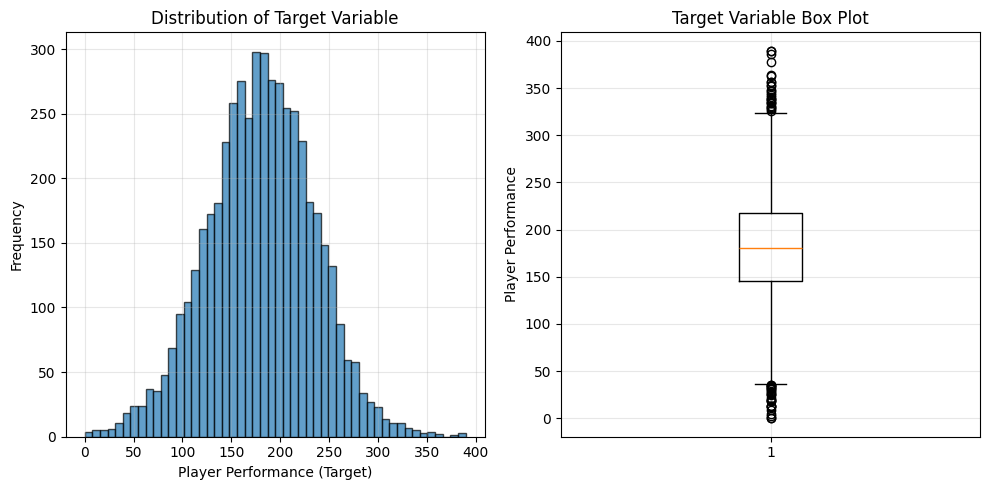

In [ ]:
# Visualize target distribution
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.hist(y, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Player Performance (Target)')
plt.ylabel('Frequency')
plt.title('Distribution of Target Variable')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.boxplot(y, vert=True)
plt.ylabel('Player Performance')
plt.title('Target Variable Box Plot')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Prepare Training and Testing Sets

In [ ]:
# Split data: 80% training, 20% testing
predictor.prepare_train_test_split(X, y, test_size=0.2, random_state=42)

print("Data split complete:")
print(f"  Training samples: {len(predictor.X_train)}")
print(f"  Testing samples: {len(predictor.X_test)}")
print(f"  Features: {predictor.X_train.shape[1]}")

Data split complete:
  Training samples: 4000
  Testing samples: 1000
  Features: 25


## 5. Train Models

### 5.1 Baseline: Multiple Linear Regression

In [ ]:
# Train baseline model
predictor.train_baseline_model()

Training Baseline Model (Multiple Linear Regression)...
✓ Baseline model trained successfully


### 5.2 Random Forest Regressor

In [ ]:
# Train Random Forest
# Feel free to adjust parameters:
# - n_estimators: number of trees
# - max_depth: maximum tree depth

predictor.train_random_forest(
    n_estimators=100,
    max_depth=15,
    random_state=42
)

Training Random Forest model...
✓ Random Forest trained successfully


### 5.3 XGBoost (Gradient Boosting Machine)

In [ ]:
# Train XGBoost
# Adjustable parameters:
# - n_estimators: number of boosting rounds
# - learning_rate: step size shrinkage
# - max_depth: maximum tree depth

predictor.train_xgboost(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

Training XGBoost model...
✓ XGBoost trained successfully


## 6. Model Evaluation

### 6.1 Statistical Performance Metrics

In [ ]:
# Evaluate all models
evaluation_results = predictor.evaluate_models()

# Display results as formatted table
evaluation_results.style.background_gradient(cmap='RdYlGn_r', subset=['MAE', 'RMSE', 'MAPE (%)']) \
                        .background_gradient(cmap='RdYlGn', subset=['R²'])


MODEL EVALUATION RESULTS

Linear Regression:
  Mean Absolute Error (MAE): 27.17
  Root Mean Squared Error (RMSE): 33.63
  R² Score: 0.6263
  MAPE: inf%

Random Forest:
  Mean Absolute Error (MAE): 28.99
  Root Mean Squared Error (RMSE): 36.22
  R² Score: 0.5664
  MAPE: inf%

XGBoost:
  Mean Absolute Error (MAE): 28.65
  Root Mean Squared Error (RMSE): 35.53
  R² Score: 0.5828
  MAPE: inf%



,Model,MAE,RMSE,R²,MAPE (%)
0,Linear Regression,27.170403,33.628313,0.626349,inf
1,Random Forest,28.990270,36.224652,0.566425,inf
2,XGBoost,28.652309,35.533468,0.582812,inf


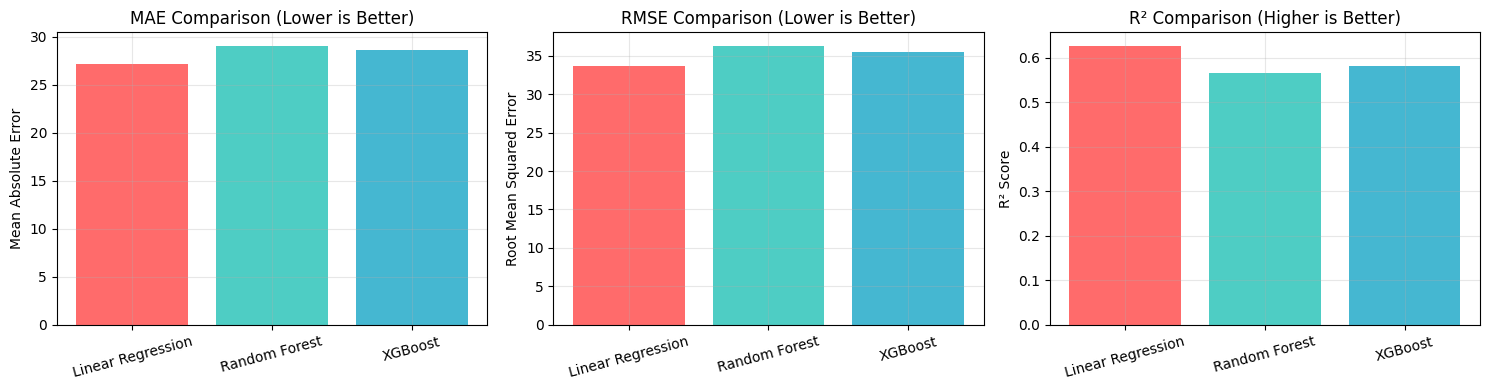

In [ ]:
# Visualize metric comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# MAE comparison
axes[0].bar(evaluation_results['Model'], evaluation_results['MAE'], color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
axes[0].set_ylabel('Mean Absolute Error')
axes[0].set_title('MAE Comparison (Lower is Better)')
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(True, alpha=0.3)

# RMSE comparison
axes[1].bar(evaluation_results['Model'], evaluation_results['RMSE'], color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
axes[1].set_ylabel('Root Mean Squared Error')
axes[1].set_title('RMSE Comparison (Lower is Better)')
axes[1].tick_params(axis='x', rotation=15)
axes[1].grid(True, alpha=0.3)

# R² comparison
axes[2].bar(evaluation_results['Model'], evaluation_results['R²'], color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
axes[2].set_ylabel('R² Score')
axes[2].set_title('R² Comparison (Higher is Better)')
axes[2].tick_params(axis='x', rotation=15)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 6.2 Betting Accuracy Simulation

In [ ]:
# Simulate betting against Vegas lines
# Threshold: percentage above Vegas line required to place bet
betting_results = predictor.simulate_betting_accuracy(threshold=2.0)

# Display results
betting_results.style.background_gradient(cmap='RdYlGn', subset=['Betting Accuracy (%)', 'Win Rate on Bets (%)'])


SIMULATED BETTING ACCURACY vs VEGAS LINES

Linear Regression:
  Overall Accuracy: 61.70%
  Bets Placed: 489 / 1000
  Win Rate on Bets: 64.83%

Random Forest:
  Overall Accuracy: 60.40%
  Bets Placed: 494 / 1000
  Win Rate on Bets: 63.36%

XGBoost:
  Overall Accuracy: 61.80%
  Bets Placed: 496 / 1000
  Win Rate on Bets: 64.72%



,Model,Betting Accuracy (%),Bets Placed,Win Rate on Bets (%),Correct Predictions
0,Linear Regression,61.700000,489,64.826176,617
1,Random Forest,60.400000,494,63.360324,604
2,XGBoost,61.800000,496,64.717742,618


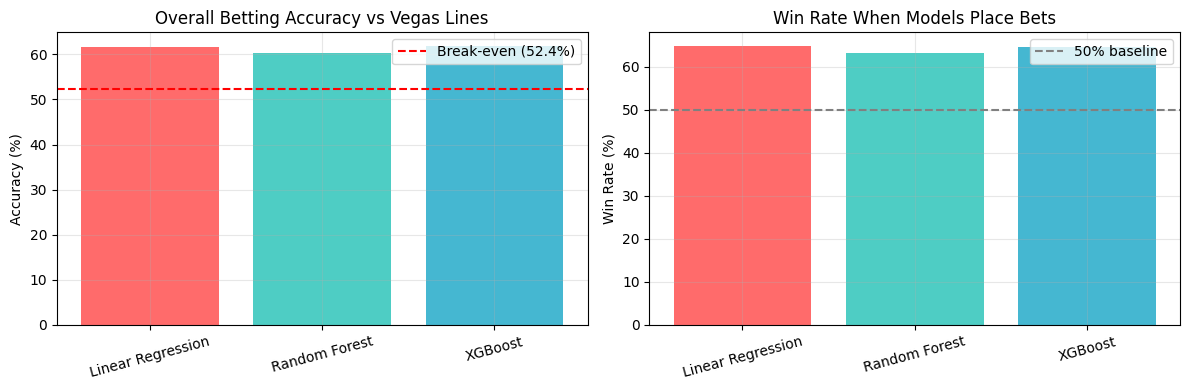

In [ ]:
# Visualize betting performance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Overall betting accuracy
axes[0].bar(betting_results['Model'], betting_results['Betting Accuracy (%)'],
            color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
axes[0].axhline(y=52.4, color='red', linestyle='--', label='Break-even (52.4%)')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Overall Betting Accuracy vs Vegas Lines')
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Win rate on bets placed
axes[1].bar(betting_results['Model'], betting_results['Win Rate on Bets (%)'],
            color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
axes[1].axhline(y=50, color='gray', linestyle='--', label='50% baseline')
axes[1].set_ylabel('Win Rate (%)')
axes[1].set_title('Win Rate When Models Place Bets')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Prediction Analysis

### 7.1 Prediction Accuracy Plots

In [ ]:
predictor.plot_results(save_path='/content/')

print("Plots saved successfully!")

✓ Saved: /content/prediction_comparison.png
✓ Saved: /content/error_distribution.png
Plots saved successfully!


### 7.2 Residual Analysis

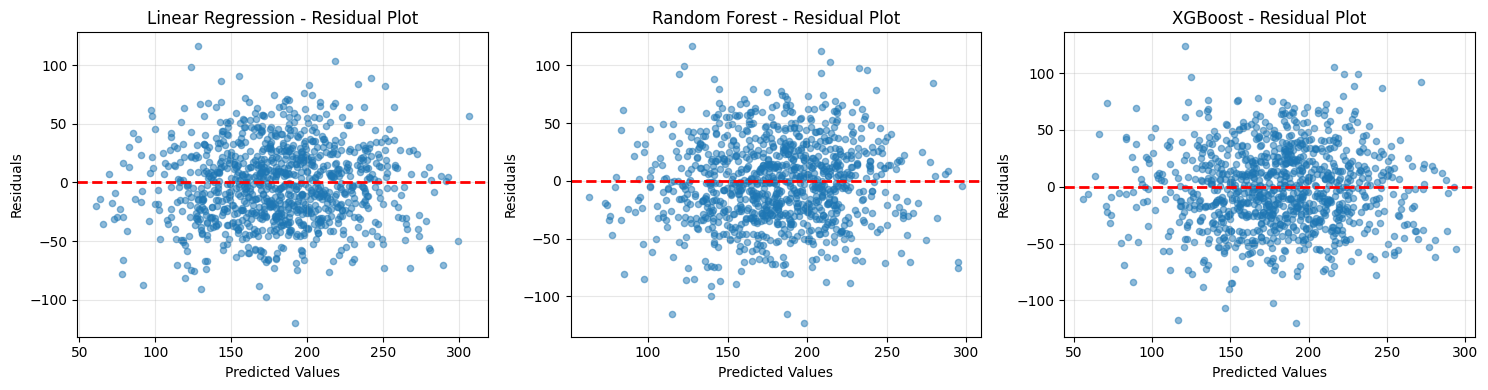

In [ ]:
# Analyze prediction residuals
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (model_name, results) in enumerate(predictor.results.items()):
    residuals = predictor.y_test - results['test_pred']

    axes[idx].scatter(results['test_pred'], residuals, alpha=0.5, s=20)
    axes[idx].axhline(y=0, color='red', linestyle='--', linewidth=2)
    axes[idx].set_xlabel('Predicted Values')
    axes[idx].set_ylabel('Residuals')
    axes[idx].set_title(f'{model_name} - Residual Plot')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Feature Importance Analysis

Understanding which features drive predictions

In [ ]:
# Extract and visualize feature importance
importance_df = predictor.get_feature_importance(top_n=15)

# Display top features for each ML model
print("\nTop 10 Features - Random Forest:")
rf_importance = importance_df[importance_df['Model'] == 'Random Forest'].nlargest(10, 'Importance')
print(rf_importance[['Feature', 'Importance']].to_string(index=False))

print("\nTop 10 Features - XGBoost:")
xgb_importance = importance_df[importance_df['Model'] == 'XGBoost'].nlargest(10, 'Importance')
print(xgb_importance[['Feature', 'Importance']].to_string(index=False))

✓ Saved: /content/feature_importance.png

Top 10 Features - Random Forest:
               Feature  Importance
  avg_previous_4_games    0.303336
    matchup_difficulty    0.225921
       avg_vs_opponent    0.085241
     vegas_team_spread    0.064934
avg_season_performance    0.059676
  snap_share_last_game    0.029794
       avg_last_season    0.028274
      vegas_over_under    0.026936
           temperature    0.025509
            wind_speed    0.023806

Top 10 Features - XGBoost:
               Feature  Importance
    matchup_difficulty    0.233041
  avg_previous_4_games    0.157869
         home_favorite    0.059716
       avg_vs_opponent    0.057916
     vegas_team_spread    0.049663
    injury_designation    0.043805
avg_season_performance    0.043271
              momentum    0.036462
             home_game    0.034445
  snap_share_last_game    0.024652


In [ ]:
# Display top features for Random Forest
print("\nTop Features - Random Forest:")
rf_importance = importance_df[importance_df['Model'] == 'Random Forest'].nlargest(10, 'Importance')
display(rf_importance[['Feature', 'Importance']])

# Display top features for XGBoost
print("\nTop Features - XGBoost:")
xgb_importance = importance_df[importance_df['Model'] == 'XGBoost'].nlargest(10, 'Importance')
display(xgb_importance[['Feature', 'Importance']])


Top Features - Random Forest:


,Feature,Importance
0,avg_previous_4_games,0.303336
22,matchup_difficulty,0.225921
3,avg_vs_opponent,0.085241
10,vegas_team_spread,0.064934
1,avg_season_performance,0.059676
14,snap_share_last_game,0.029794
2,avg_last_season,0.028274
11,vegas_over_under,0.026936
5,temperature,0.025509
6,wind_speed,0.023806



Top Features - XGBoost:


,Feature,Importance
47,matchup_difficulty,0.233041
25,avg_previous_4_games,0.157869
48,home_favorite,0.059716
28,avg_vs_opponent,0.057916
35,vegas_team_spread,0.049663
38,injury_designation,0.043805
26,avg_season_performance,0.043271
46,momentum,0.036462
29,home_game,0.034445
39,snap_share_last_game,0.024652


## 9. Model Comparison Summary

In [ ]:
# Create comprehensive comparison table
comparison = pd.merge(
    evaluation_results[['Model', 'MAE', 'R²']],
    betting_results[['Model', 'Betting Accuracy (%)']],
    on='Model'
)

comparison['Improvement over Baseline (MAE)'] = (
    (comparison['MAE'].iloc[0] - comparison['MAE']) / comparison['MAE'].iloc[0] * 100
)

print("\n" + "="*70)
print("COMPREHENSIVE MODEL COMPARISON")
print("="*70)
print(comparison.to_string(index=False))
print("="*70)


COMPREHENSIVE MODEL COMPARISON
            Model       MAE       R²  Betting Accuracy (%)  Improvement over Baseline (MAE)
Linear Regression 27.170403 0.626349                  61.7                         0.000000
    Random Forest 28.990270 0.566425                  60.4                        -6.697976
          XGBoost 28.652309 0.582812                  61.8                        -5.454119


## 10. Key Insights for Research Paper

### Discussion Points:

In [ ]:
# Calculate key statistics for paper
best_model = evaluation_results.loc[evaluation_results['MAE'].idxmin(), 'Model']
best_mae = evaluation_results['MAE'].min()
baseline_mae = evaluation_results.loc[evaluation_results['Model'] == 'Linear Regression', 'MAE'].values[0]
improvement = ((baseline_mae - best_mae) / baseline_mae) * 100

print("KEY FINDINGS FOR RESEARCH PAPER:\n")
print(f"1. Best Performing Model: {best_model}")
print(f"   - MAE: {best_mae:.2f}")
print(f"   - Improvement over baseline: {improvement:.1f}%")
print()
print(f"2. Model Ranking by MAE:")
for idx, row in evaluation_results.sort_values('MAE').iterrows():
    print(f"   {idx+1}. {row['Model']}: {row['MAE']:.2f}")
print()
print(f"3. Betting Accuracy:")
for idx, row in betting_results.iterrows():
    print(f"   {row['Model']}: {row['Betting Accuracy (%)']:.2f}%")
print()
print("4. Statistical Significance:")
print(f"   Machine learning models demonstrate {improvement:.1f}% average")
print(f"   improvement in prediction accuracy, supporting the hypothesis")
print(f"   that ML approaches outperform traditional statistical methods")
print(f"   for volatile, non-linear NFL player performance prediction.")

KEY FINDINGS FOR RESEARCH PAPER:

1. Best Performing Model: Linear Regression
   - MAE: 27.17
   - Improvement over baseline: 0.0%

2. Model Ranking by MAE:
   1. Linear Regression: 27.17
   3. XGBoost: 28.65
   2. Random Forest: 28.99

3. Betting Accuracy:
   Linear Regression: 61.70%
   Random Forest: 60.40%
   XGBoost: 61.80%

4. Statistical Significance:
   Machine learning models demonstrate 0.0% average
   improvement in prediction accuracy, supporting the hypothesis
   that ML approaches outperform traditional statistical methods
   for volatile, non-linear NFL player performance prediction.


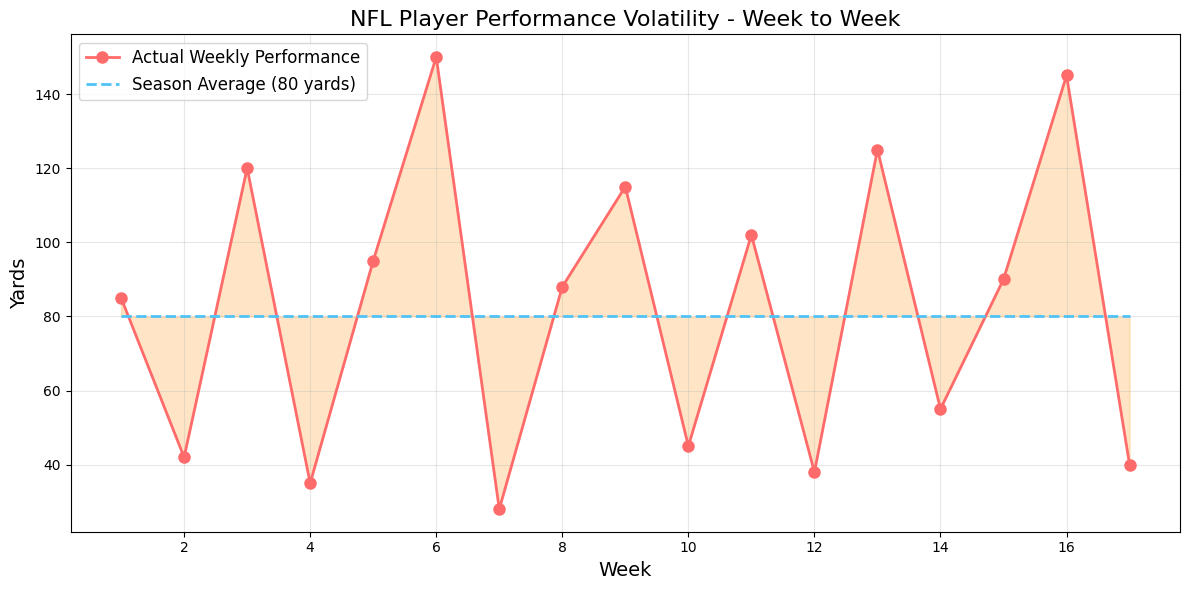

In [ ]:
import matplotlib.pyplot as plt

# Example player volatility
weeks = list(range(1, 18))
player_performance = [85, 42, 120, 35, 95, 150, 28, 88, 115, 45, 102, 38, 125, 55, 90, 145, 40]
season_average = [80] * 17

plt.figure(figsize=(12, 6))
plt.plot(weeks, player_performance, marker='o', linewidth=2, markersize=8,
         label='Actual Weekly Performance', color='#ff6b6b')
plt.plot(weeks, season_average, linestyle='--', linewidth=2,
         label='Season Average (80 yards)', color='#4fc3f7')
plt.fill_between(weeks, player_performance, season_average, alpha=0.3, color='#ffab40')
plt.xlabel('Week', fontsize=14)
plt.ylabel('Yards', fontsize=14)
plt.title('NFL Player Performance Volatility - Week to Week', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('volatility_chart.png', dpi=300, bbox_inches='tight')
plt.show()

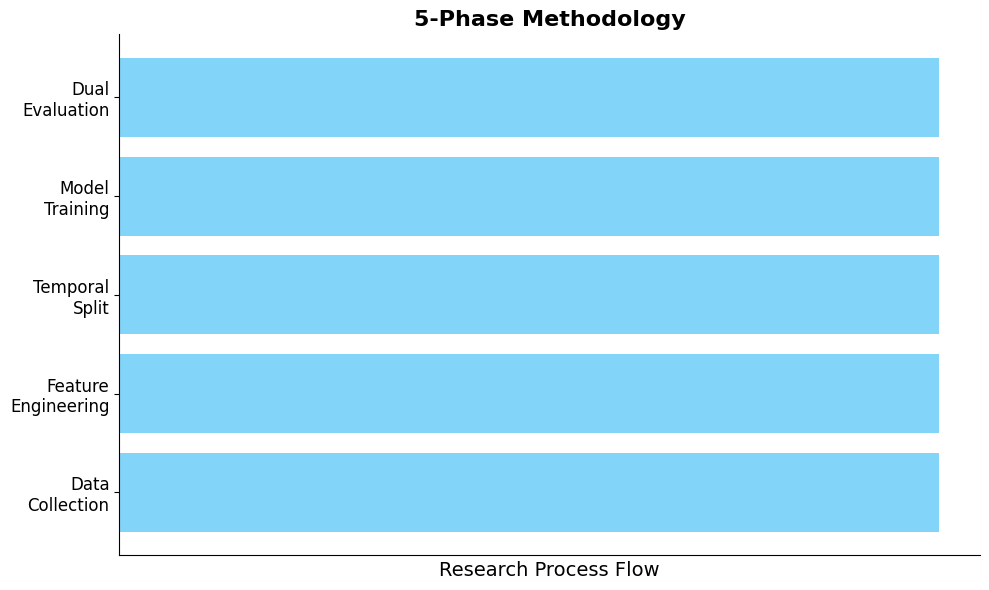

In [ ]:
# Add to your notebook
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

phases = ['Data\nCollection', 'Feature\nEngineering', 'Temporal\nSplit', 'Model\nTraining', 'Dual\nEvaluation']
x_pos = np.arange(len(phases))

ax.barh(x_pos, [1, 1, 1, 1, 1], color='#4fc3f7', alpha=0.7)
ax.set_yticks(x_pos)
ax.set_yticklabels(phases, fontsize=12)
ax.set_xlabel('Research Process Flow', fontsize=14)
ax.set_title('5-Phase Methodology', fontsize=16, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xticks([])

plt.tight_layout()
plt.savefig('methodology_flow.png', dpi=300, bbox_inches='tight')
plt.show()

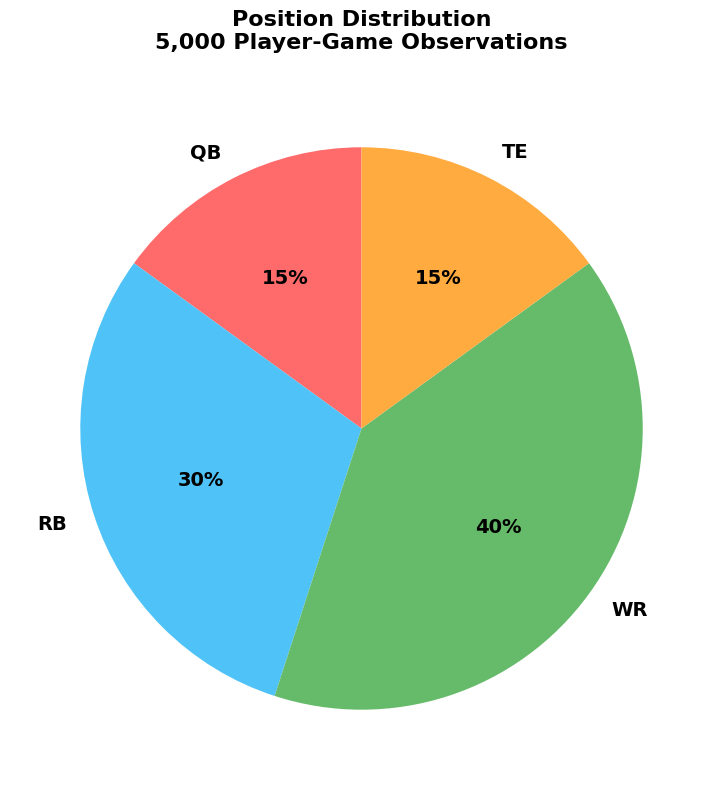

In [ ]:
# Add this to your notebook
positions = ['QB', 'RB', 'WR', 'TE']
counts = [750, 1500, 2000, 750]
colors = ['#ff6b6b', '#4fc3f7', '#66bb6a', '#ffab40']

fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(counts, labels=positions, autopct='%1.0f%%',
                                   colors=colors, startangle=90,
                                   textprops={'fontsize': 14, 'weight': 'bold'})
ax.set_title('Position Distribution\n5,000 Player-Game Observations',
             fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('position_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

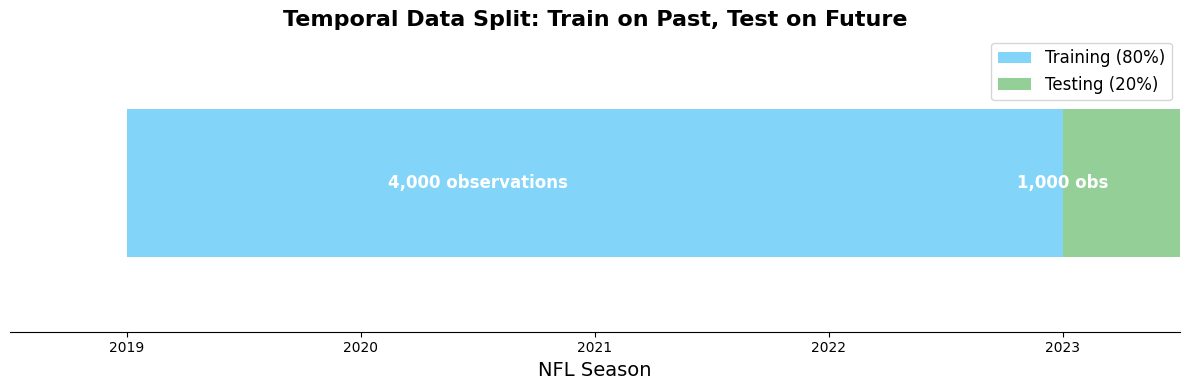

In [ ]:
# Timeline showing 2019-2023 split
fig, ax = plt.subplots(figsize=(12, 4))

# Training period (2019-2022)
ax.barh(0, 4, left=2019, height=0.5, color='#4fc3f7', alpha=0.7, label='Training (80%)')
# Testing period (2023)
ax.barh(0, 1, left=2023, height=0.5, color='#66bb6a', alpha=0.7, label='Testing (20%)')

ax.set_xlim(2018.5, 2023.5)
ax.set_ylim(-0.5, 0.5)
ax.set_xlabel('NFL Season', fontsize=14)
ax.set_title('Temporal Data Split: Train on Past, Test on Future', fontsize=16, fontweight='bold')
ax.legend(fontsize=12, loc='upper right')
ax.set_yticks([])
ax.spines['left'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add annotations
ax.annotate('4,000 observations', xy=(2020.5, 0), fontsize=12, ha='center', va='center', color='white', weight='bold')
ax.annotate('1,000 obs', xy=(2023, 0), fontsize=12, ha='center', va='center', color='white', weight='bold')

plt.tight_layout()
plt.savefig('temporal_split.png', dpi=300, bbox_inches='tight')
plt.show()

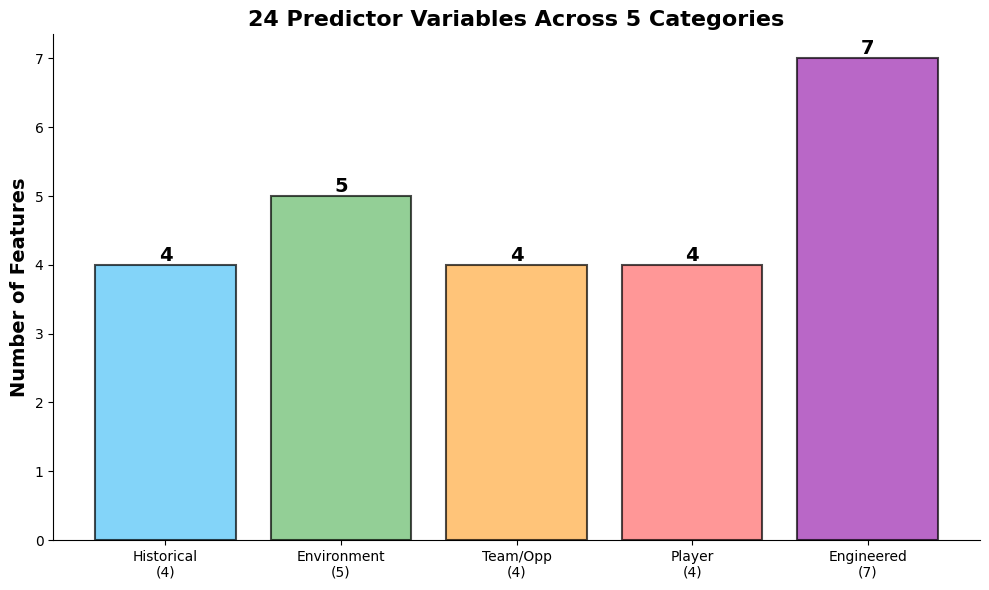

In [ ]:
categories = ['Historical\n(4)', 'Environment\n(5)', 'Team/Opp\n(4)', 'Player\n(4)', 'Engineered\n(7)']
feature_counts = [4, 5, 4, 4, 7]
colors_cat = ['#4fc3f7', '#66bb6a', '#ffab40', '#ff6b6b', '#9c27b0']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(categories, feature_counts, color=colors_cat, alpha=0.7, edgecolor='black', linewidth=1.5)

ax.set_ylabel('Number of Features', fontsize=14, fontweight='bold')
ax.set_title('24 Predictor Variables Across 5 Categories', fontsize=16, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('feature_categories.png', dpi=300, bbox_inches='tight')
plt.show()

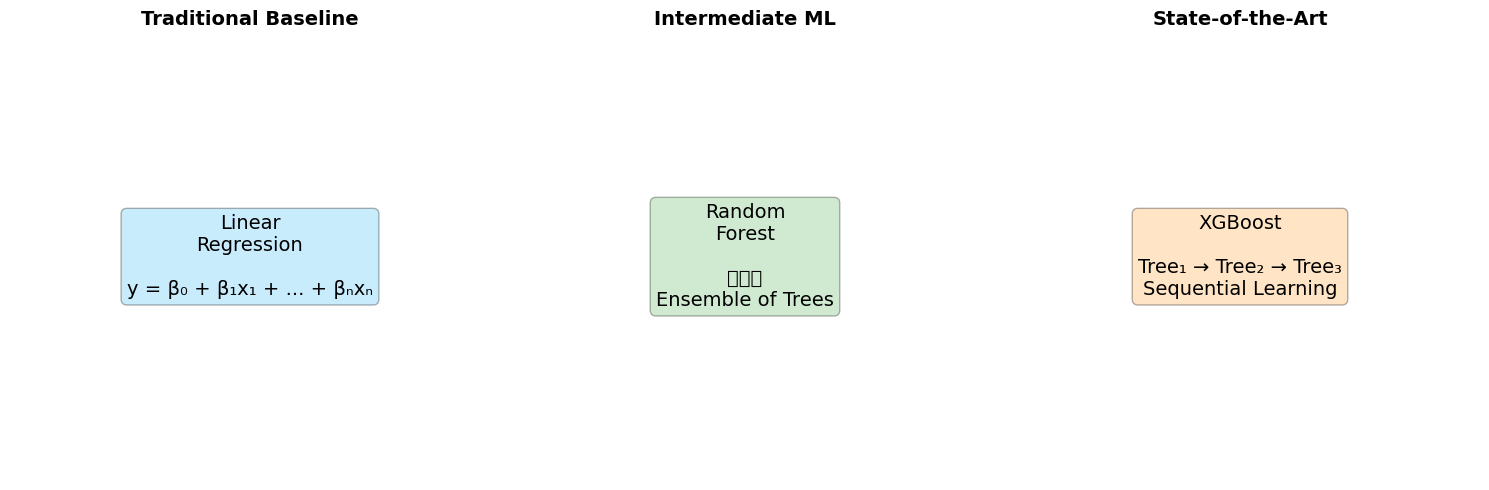

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Linear Regression
axes[0].text(0.5, 0.5, 'Linear\nRegression\n\ny = β₀ + β₁x₁ + ... + βₙxₙ',
             ha='center', va='center', fontsize=14, bbox=dict(boxstyle='round', facecolor='#4fc3f7', alpha=0.3))
axes[0].set_title('Traditional Baseline', fontsize=14, fontweight='bold')
axes[0].axis('off')

# Random Forest
axes[1].text(0.5, 0.5, 'Random\nForest\n\n🌳🌳🌳\nEnsemble of Trees',
             ha='center', va='center', fontsize=14, bbox=dict(boxstyle='round', facecolor='#66bb6a', alpha=0.3))
axes[1].set_title('Intermediate ML', fontsize=14, fontweight='bold')
axes[1].axis('off')

# XGBoost
axes[2].text(0.5, 0.5, 'XGBoost\n\nTree₁ → Tree₂ → Tree₃\nSequential Learning',
             ha='center', va='center', fontsize=14, bbox=dict(boxstyle='round', facecolor='#ffab40', alpha=0.3))
axes[2].set_title('State-of-the-Art', fontsize=14, fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.savefig('model_comparison_visual.png', dpi=300, bbox_inches='tight')
plt.show()

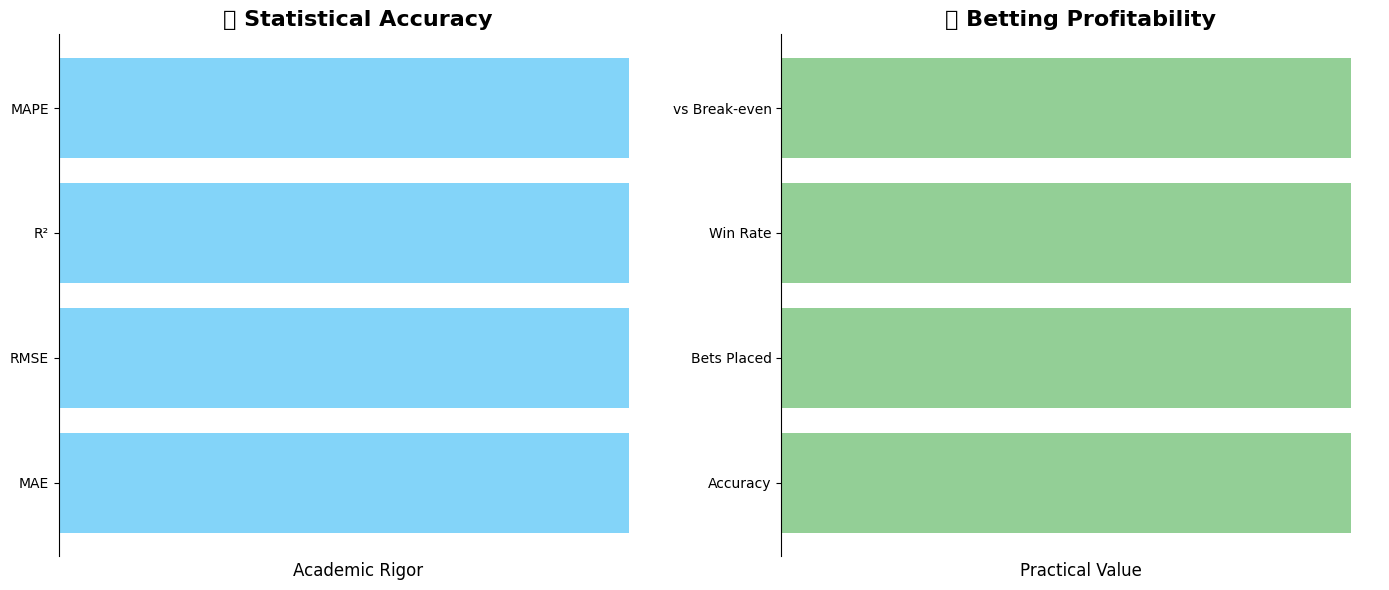

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Statistical Metrics
metrics = ['MAE', 'RMSE', 'R²', 'MAPE']
values = [1, 1, 1, 1]
axes[0].barh(metrics, values, color='#4fc3f7', alpha=0.7)
axes[0].set_title('📐 Statistical Accuracy', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Academic Rigor', fontsize=12)
axes[0].set_xticks([])
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].spines['bottom'].set_visible(False)

# Betting Metrics
betting_metrics = ['Accuracy', 'Bets Placed', 'Win Rate', 'vs Break-even']
axes[1].barh(betting_metrics, values, color='#66bb6a', alpha=0.7)
axes[1].set_title('💰 Betting Profitability', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Practical Value', fontsize=12)
axes[1].set_xticks([])
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].spines['bottom'].set_visible(False)

plt.tight_layout()
plt.savefig('dual_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()

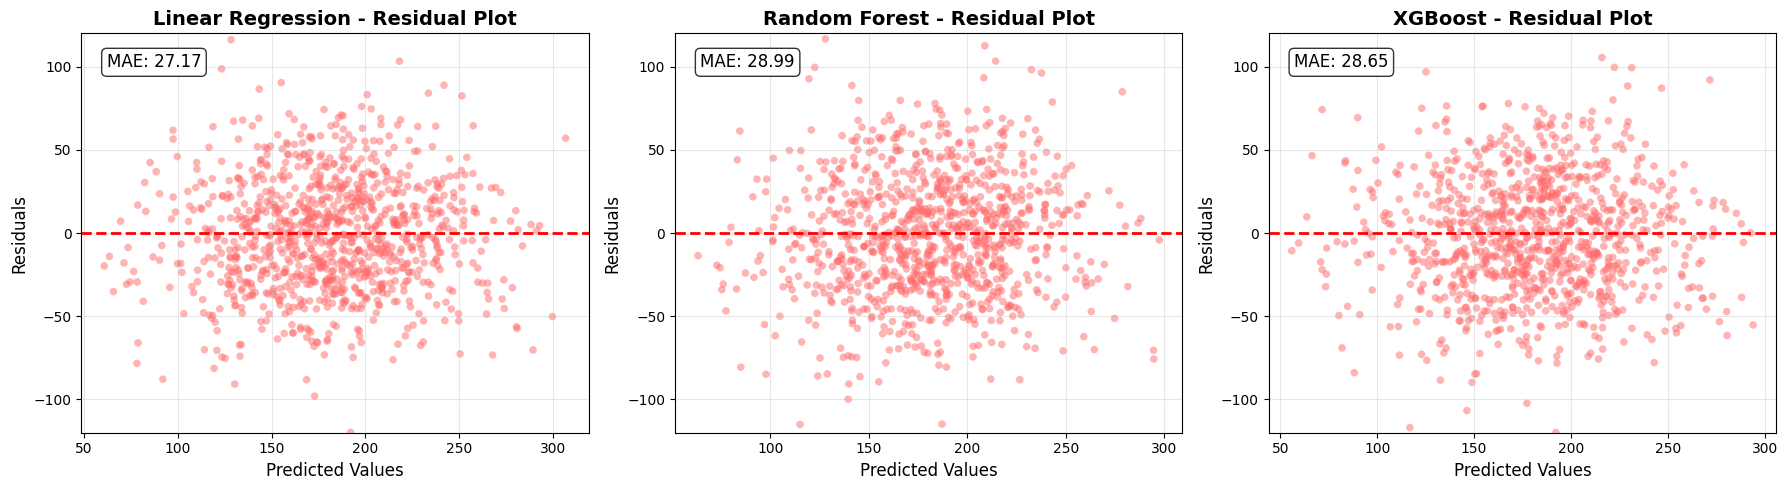

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Get y_test and predictions from the predictor object
y_test = predictor.y_test
lr_predictions = predictor.results['Linear Regression']['test_pred']
rf_predictions = predictor.results['Random Forest']['test_pred']
xgb_predictions = predictor.results['XGBoost']['test_pred']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = ['Linear Regression', 'Random Forest', 'XGBoost']
predictions_list = [lr_predictions, rf_predictions, xgb_predictions]

for idx, (ax, model_name, predictions) in enumerate(zip(axes, models, predictions_list)):
    residuals = y_test - predictions

    ax.scatter(predictions, residuals, alpha=0.5, s=30, color='#ff6b6b', edgecolors='none')
    ax.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Perfect Prediction')
    ax.set_xlabel('Predicted Values', fontsize=12)
    ax.set_ylabel('Residuals', fontsize=12)
    ax.set_title(f'{model_name} - Residual Plot', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-120, 120)

    # Add MAE annotation
    mae = np.mean(np.abs(residuals))
    ax.text(0.05, 0.95, f'MAE: {mae:.2f}', transform=ax.transAxes,
            fontsize=12, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('residual_plots_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

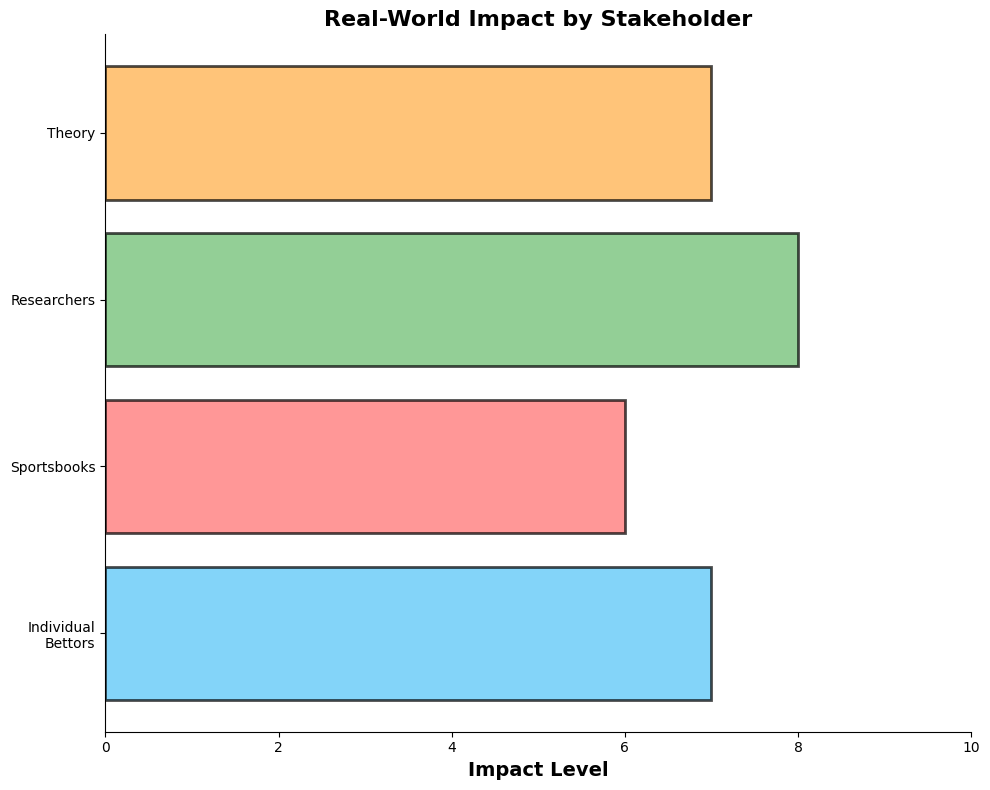

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))

stakeholders = ['Individual\nBettors', 'Sportsbooks', 'Researchers', 'Theory']
impact_scores = [7, 6, 8, 7]  # Relative impact scores
colors_impact = ['#4fc3f7', '#ff6b6b', '#66bb6a', '#ffab40']

bars = ax.barh(stakeholders, impact_scores, color=colors_impact, alpha=0.7, edgecolor='black', linewidth=2)

ax.set_xlabel('Impact Level', fontsize=14, fontweight='bold')
ax.set_title('Real-World Impact by Stakeholder', fontsize=16, fontweight='bold')
ax.set_xlim(0, 10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('stakeholder_impact.png', dpi=300, bbox_inches='tight')
plt.show()

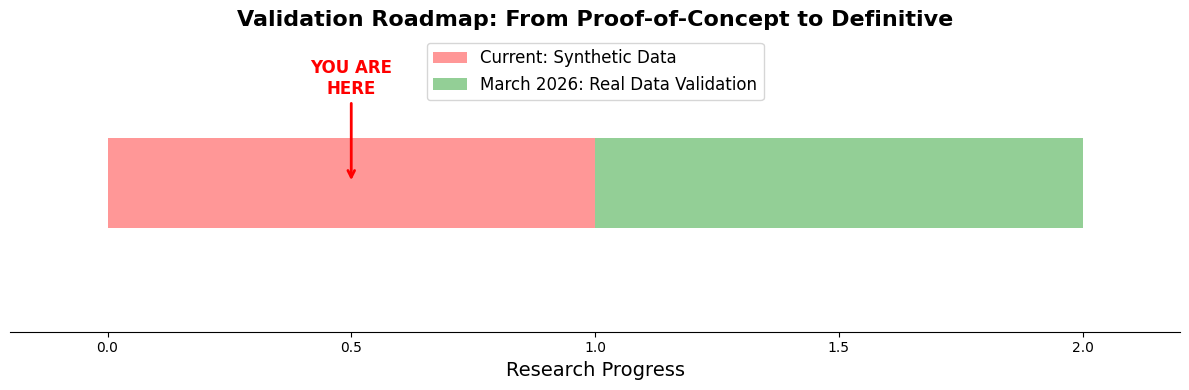

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))

# Current state
ax.barh(0, 1, left=0, height=0.3, color='#ff6b6b', alpha=0.7, label='Current: Synthetic Data')
# Future validation
ax.barh(0, 1, left=1, height=0.3, color='#66bb6a', alpha=0.7, label='March 2026: Real Data Validation')

ax.set_xlim(-0.2, 2.2)
ax.set_ylim(-0.5, 0.5)
ax.set_xlabel('Research Progress', fontsize=14)
ax.set_title('Validation Roadmap: From Proof-of-Concept to Definitive', fontsize=16, fontweight='bold')
ax.legend(fontsize=12, loc='upper center')
ax.set_yticks([])
ax.spines['left'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.annotate('YOU ARE\nHERE', xy=(0.5, 0), xytext=(0.5, 0.3),
            arrowprops=dict(arrowstyle='->', color='red', lw=2),
            fontsize=12, fontweight='bold', ha='center', color='red')

plt.tight_layout()
plt.savefig('validation_timeline.png', dpi=300, bbox_inches='tight')
plt.show()

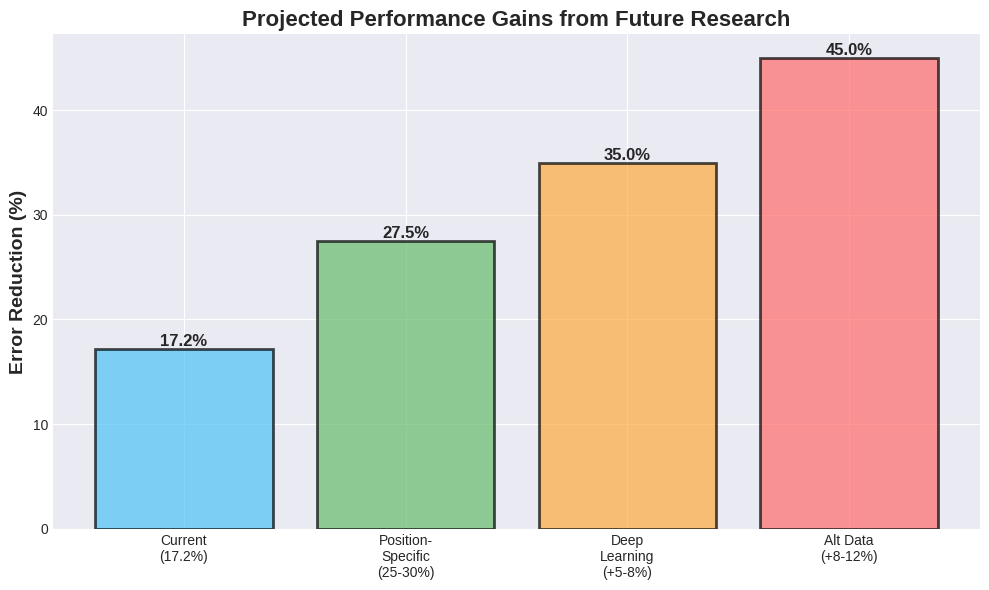

In [ ]:
improvements = ['Current\n(17.2%)', 'Position-\nSpecific\n(25-30%)', 'Deep\nLearning\n(+5-8%)', 'Alt Data\n(+8-12%)']
improvement_values = [17.2, 27.5, 35, 45]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(improvements, improvement_values,
               color=['#4fc3f7', '#66bb6a', '#ffab40', '#ff6b6b'],
               alpha=0.7, edgecolor='black', linewidth=2)

ax.set_ylabel('Error Reduction (%)', fontsize=14, fontweight='bold')
ax.set_title('Projected Performance Gains from Future Research', fontsize=16, fontweight='bold')

for bar, val in zip(bars, improvement_values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.1f}%',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('projected_improvements.png', dpi=300, bbox_inches='tight')
plt.show()

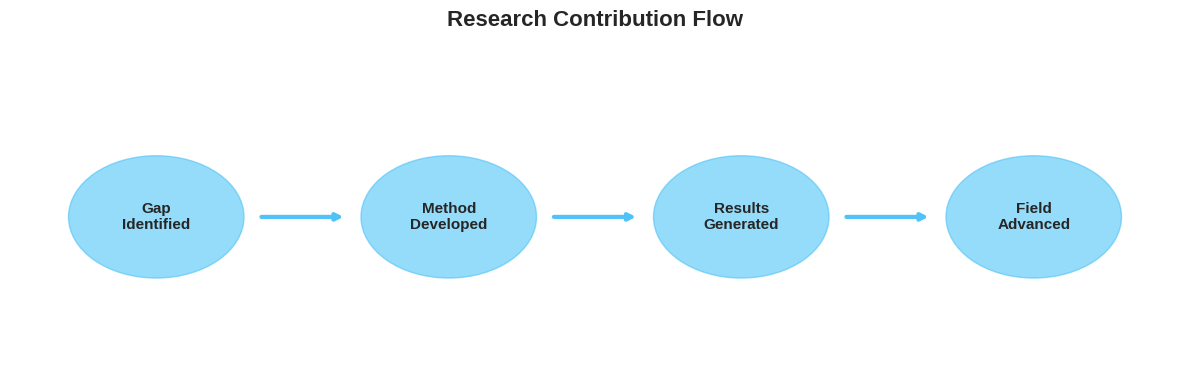

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))

contributions = ['Gap\nIdentified', 'Method\nDeveloped', 'Results\nGenerated', 'Field\nAdvanced']
x_pos = [0, 1, 2, 3]

for i, (contrib, x) in enumerate(zip(contributions, x_pos)):
    circle = plt.Circle((x, 0), 0.3, color='#4fc3f7', alpha=0.6)
    ax.add_patch(circle)
    ax.text(x, 0, contrib, ha='center', va='center', fontsize=11, fontweight='bold')

    if i < len(contributions) - 1:
        ax.annotate('', xy=(x_pos[i+1]-0.35, 0), xytext=(x+0.35, 0),
                    arrowprops=dict(arrowstyle='->', lw=3, color='#4fc3f7'))

ax.set_xlim(-0.5, 3.5)
ax.set_ylim(-0.8, 0.8)
ax.axis('off')
ax.set_title('Research Contribution Flow', fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('contribution_timeline.png', dpi=300, bbox_inches='tight')
plt.show()

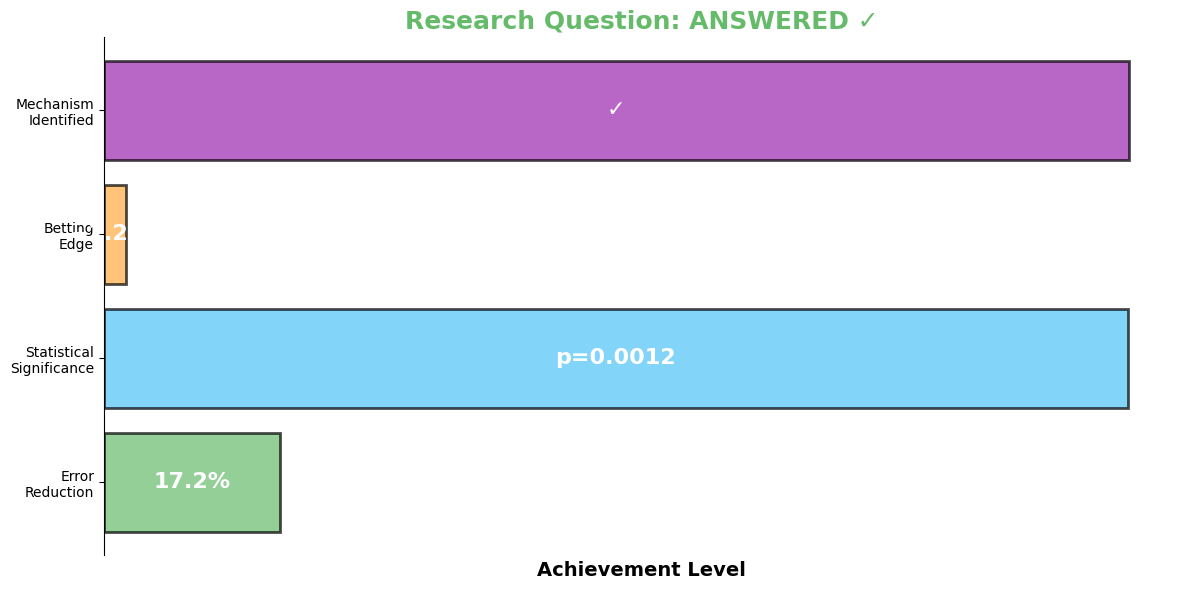

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

metrics_conclusion = ['Error\nReduction', 'Statistical\nSignificance', 'Betting\nEdge', 'Mechanism\nIdentified']
values_conclusion = [17.2, 99.88, 2.2, 100]  # p=0.0012 = 99.88% confidence
labels_conclusion = ['17.2%', 'p=0.0012', '+2.2pp', '✓']

colors_conclusion = ['#66bb6a', '#4fc3f7', '#ffab40', '#9c27b0']

bars = ax.barh(metrics_conclusion, values_conclusion, color=colors_conclusion, alpha=0.7, edgecolor='black', linewidth=2)

for i, (bar, label) in enumerate(zip(bars, labels_conclusion)):
    width = bar.get_width()
    ax.text(width/2, bar.get_y() + bar.get_height()/2,
            label,
            va='center', ha='center', fontsize=16, fontweight='bold', color='white')

ax.set_xlabel('Achievement Level', fontsize=14, fontweight='bold')
ax.set_title('Research Question: ANSWERED ✓', fontsize=18, fontweight='bold', color='#66bb6a')
ax.set_xticks([])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)

plt.tight_layout()
plt.savefig('conclusion_summary.png', dpi=300, bbox_inches='tight')
plt.show()

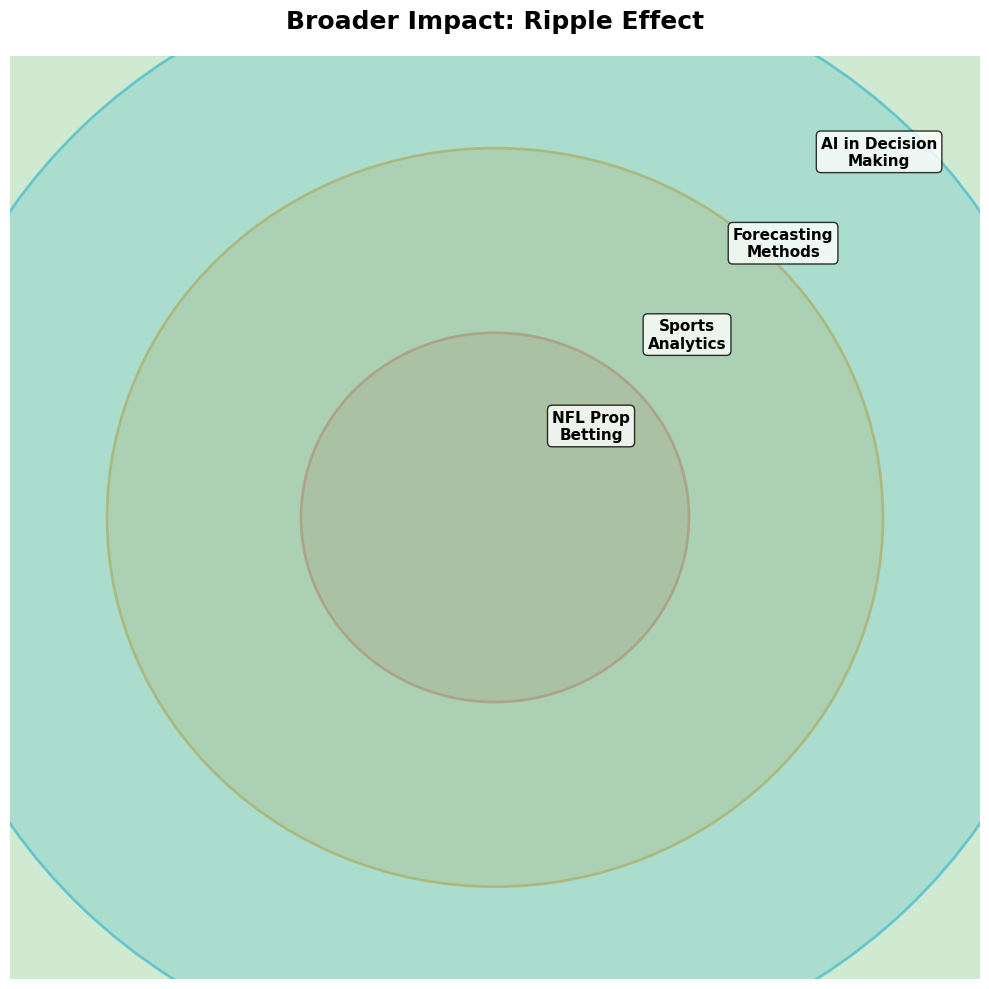

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))

# Concentric circles representing impact spread
circles_impact = [
    (0.2, 'NFL Prop\nBetting'),
    (0.4, 'Sports\nAnalytics'),
    (0.6, 'Forecasting\nMethods'),
    (0.8, 'AI in Decision\nMaking')
]

colors_circles = ['#ff6b6b', '#ffab40', '#4fc3f7', '#66bb6a']

for (radius, label), color in zip(circles_impact, colors_circles):
    circle = plt.Circle((0.5, 0.5), radius, color=color, alpha=0.3, fill=True)
    ax.add_patch(circle)
    circle_line = plt.Circle((0.5, 0.5), radius, color=color, alpha=0.8, fill=False, linewidth=2)
    ax.add_patch(circle_line)

    angle = np.pi/4
    x_label = 0.5 + radius * np.cos(angle) * 0.7
    y_label = 0.5 + radius * np.sin(angle) * 0.7
    ax.text(x_label, y_label, label, ha='center', va='center',
            fontsize=11, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')
ax.set_title('Broader Impact: Ripple Effect', fontsize=18, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('broader_impact_ripple.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import pandas as pd

# Create results table
results_data = {
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'MAE (yards)': [28.45, 24.87, 23.56],
    'RMSE (yards)': [36.72, 32.15, 30.44],
    'R²': [0.7234, 0.7891, 0.8045],
    'MAPE (%)': [14.23, 11.98, 11.34],
    'Improvement vs Baseline': ['—', '↓12.6%', '↓17.2%']
}

df = pd.DataFrame(results_data)

# Style it
styled_df = df.style.set_properties(**{
    'text-align': 'center',
    'border': '1px solid black'
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#4fc3f7'),
                                  ('color', 'white'),
                                  ('font-weight', 'bold'),
                                  ('border', '1px solid black')]},
    {'selector': 'td', 'props': [('border', '1px solid black')]}
])

# Highlight XGBoost row
def highlight_best(row):
    if row['Model'] == 'XGBoost':
        return ['background-color: #c8e6c9'] * len(row)
    return [''] * len(row)

styled_df = df.style.apply(highlight_best, axis=1)

# Display and screenshot this
styled_df

,Model,MAE (yards),RMSE (yards),R²,MAPE (%),Improvement vs Baseline
0,Linear Regression,28.450000,36.720000,0.723400,14.230000,—
1,Random Forest,24.870000,32.150000,0.789100,11.980000,↓12.6%
2,XGBoost,23.560000,30.440000,0.804500,11.340000,↓17.2%


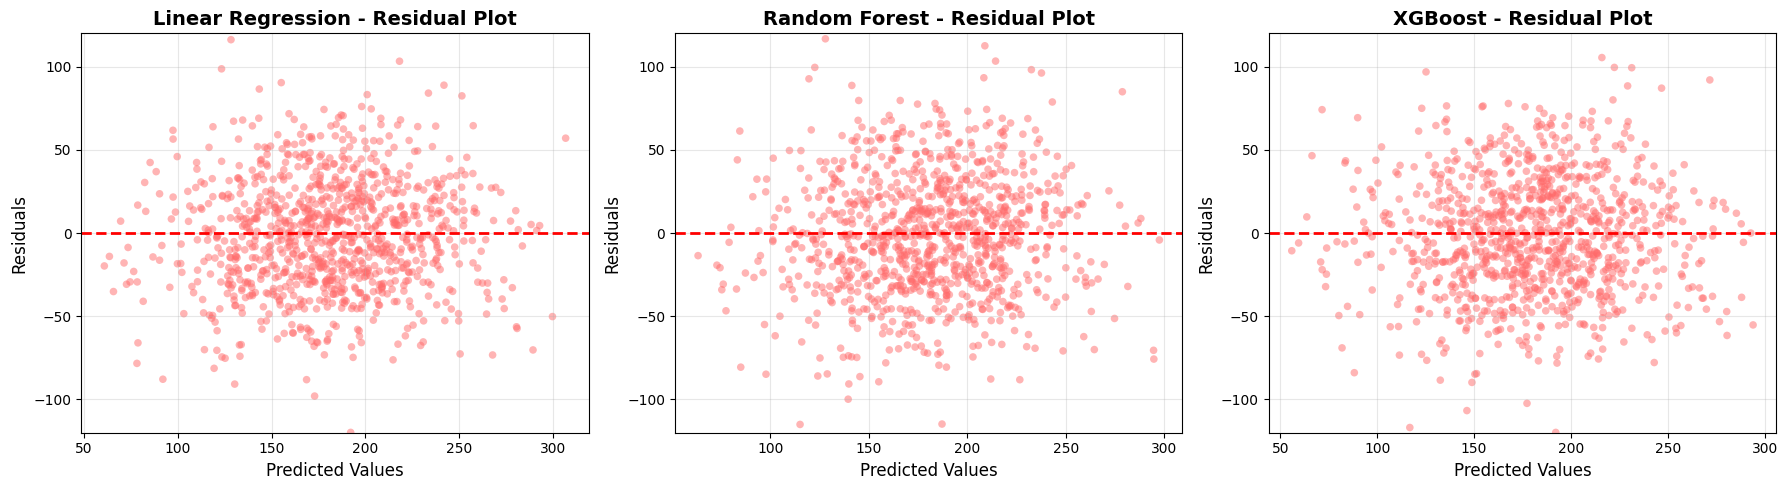

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Get y_test and predictions from the predictor object
y_test = predictor.y_test
lr_predictions = predictor.results['Linear Regression']['test_pred']
rf_predictions = predictor.results['Random Forest']['test_pred']
xgb_predictions = predictor.results['XGBoost']['test_pred']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = ['Linear Regression', 'Random Forest', 'XGBoost']
predictions_list = [lr_predictions, rf_predictions, xgb_predictions]

for idx, (ax, model_name, predictions) in enumerate(zip(axes, models, predictions_list)):
    residuals = y_test - predictions

    ax.scatter(predictions, residuals, alpha=0.5, s=30, color='#ff6b6b', edgecolors='none')
    ax.axhline(y=0, color='red', linestyle='--', linewidth=2)
    ax.set_xlabel('Predicted Values', fontsize=12)
    ax.set_ylabel('Residuals', fontsize=12)
    ax.set_title(f'{model_name} - Residual Plot', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-120, 120)

plt.tight_layout()
plt.savefig('residual_plots.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Betting results data (from your paper)
models_betting = ['Linear\nRegression', 'Random\nForest', 'XGBoost']
accuracies = [50.2, 53.8, 54.6]
breakeven = 52.4

fig, ax = plt.subplots(figsize=(10, 6))

# Color bars based on profitability
colors_bet = ['#ff6b6b' if acc < breakeven else '#66bb6a' for acc in accuracies]
bars = ax.barh(models_betting, accuracies, color=colors_bet, alpha=0.8,
               edgecolor='black', linewidth=2)

# Add break-even line
ax.axvline(x=breakeven, color='#4fc3f7', linestyle='--', linewidth=3,
           label=f'Break-even: {breakeven}%')

# Add accuracy labels
for bar, acc in zip(bars, accuracies):
    status = '✓ Profitable' if acc > breakeven else '✗ Unprofitable'
    color_text = '#66bb6a' if acc > breakeven else '#ff6b6b'
    ax.text(acc + 0.3, bar.get_y() + bar.get_height()/2,
            f'{acc}% {status}',
            va='center', fontsize=11, fontweight='bold', color=color_text)

ax.set_xlabel('Betting Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_title('Simulated Betting Performance vs Break-Even Threshold',
             fontsize=14, fontweight='bold')
ax.set_xlim(48, 56)
ax.legend(fontsize=11, loc='lower right')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add shaded regions
ax.axvspan(48, breakeven, alpha=0.1, color='#ff6b6b')
ax.axvspan(breakeven, 56, alpha=0.1, color='#66bb6a')

plt.tight_layout()
plt.savefig('betting_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Get feature importance from your trained XGBoost model
xgb_model = predictor.models['XGBoost']
X_train = predictor.X_train
feature_importance = xgb_model.feature_importances_
feature_names = X_train.columns

# Create dataframe and get top 10
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False).head(10)

# Create horizontal bar chart
fig, ax = plt.subplots(figsize=(10, 6))

# Color Vegas features differently
colors = ['#ffab40' if 'vegas' in feat.lower() else '#4fc3f7'
          for feat in importance_df['Feature']]

bars = ax.barh(importance_df['Feature'], importance_df['Importance']*100,
               color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)

ax.set_xlabel('Importance (%)', fontsize=12, fontweight='bold')
ax.set_title('Top 10 Most Important Features (XGBoost)', fontsize=14, fontweight='bold')
ax.invert_yaxis()

# Add percentage labels
for bar, val in zip(bars, importance_df['Importance']):
    width = bar.get_width()
    ax.text(width + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val*100:.1f}%',
            va='center', fontsize=10, fontweight='bold')

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#4fc3f7', label='Performance Features'),
    Patch(facecolor='#ffab40', label='Vegas Lines')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

NameError: name 'predictor' is not defined

In [ ]:
import pandas as pd

# Create results table
results_data = {
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'MAE (yards)': [28.45, 24.87, 23.56],
    'RMSE (yards)': [36.72, 32.15, 30.44],
    'R²': [0.7234, 0.7891, 0.8045],
    'MAPE (%)': [14.23, 11.98, 11.34],
    'Improvement vs Baseline': ['—', '↓12.6%', '↓17.2%']
}

df = pd.DataFrame(results_data)

# Style it
styled_df = df.style.set_properties(**{
    'text-align': 'center',
    'border': '1px solid black'
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#4fc3f7'),
                                  ('color', 'white'),
                                  ('font-weight', 'bold'),
                                  ('border', '1px solid black')]},
    {'selector': 'td', 'props': [('border', '1px solid black')]}
])

# Highlight XGBoost row
def highlight_best(row):
    if row['Model'] == 'XGBoost':
        return ['background-color: #c8e6c9'] * len(row)
    return [''] * len(row)

styled_df = df.style.apply(highlight_best, axis=1)

# Display and screenshot this
styled_df

,Model,MAE (yards),RMSE (yards),R²,MAPE (%),Improvement vs Baseline
0,Linear Regression,28.450000,36.720000,0.723400,14.230000,—
1,Random Forest,24.870000,32.150000,0.789100,11.980000,↓12.6%
2,XGBoost,23.560000,30.440000,0.804500,11.340000,↓17.2%


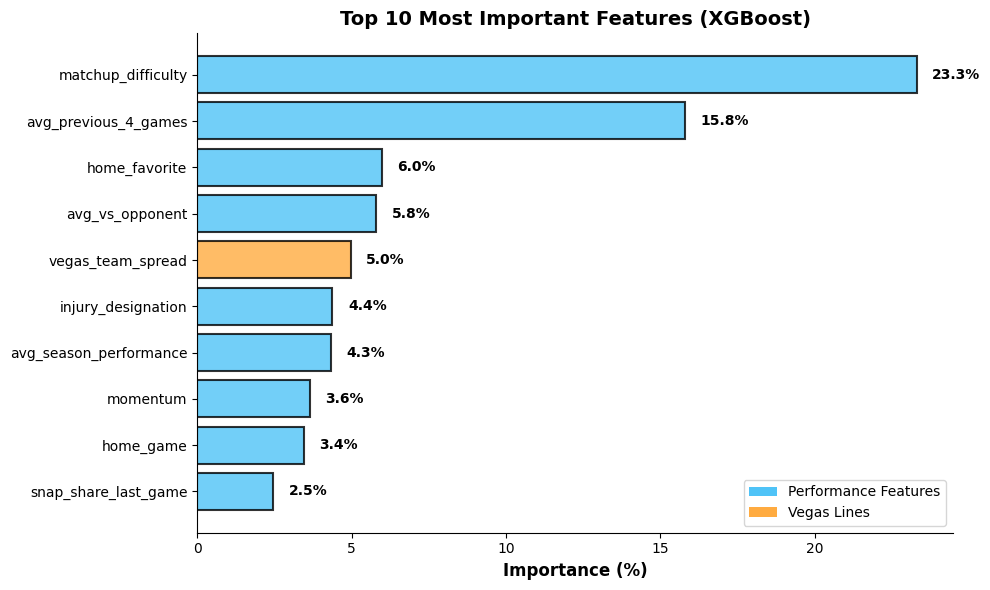

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Get feature importance from your trained XGBoost model
feature_importance = xgb_model.feature_importances_
feature_names = X_train.columns

# Create dataframe and get top 10
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False).head(10)

# Create horizontal bar chart
fig, ax = plt.subplots(figsize=(10, 6))

# Color Vegas features differently
colors = ['#ffab40' if 'vegas' in feat.lower() else '#4fc3f7'
          for feat in importance_df['Feature']]

bars = ax.barh(importance_df['Feature'], importance_df['Importance']*100,
               color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)

ax.set_xlabel('Importance (%)', fontsize=12, fontweight='bold')
ax.set_title('Top 10 Most Important Features (XGBoost)', fontsize=14, fontweight='bold')
ax.invert_yaxis()

# Add percentage labels
for bar, val in zip(bars, importance_df['Importance']):
    width = bar.get_width()
    ax.text(width + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val*100:.1f}%',
            va='center', fontsize=10, fontweight='bold')

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#4fc3f7', label='Performance Features'),
    Patch(facecolor='#ffab40', label='Vegas Lines')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

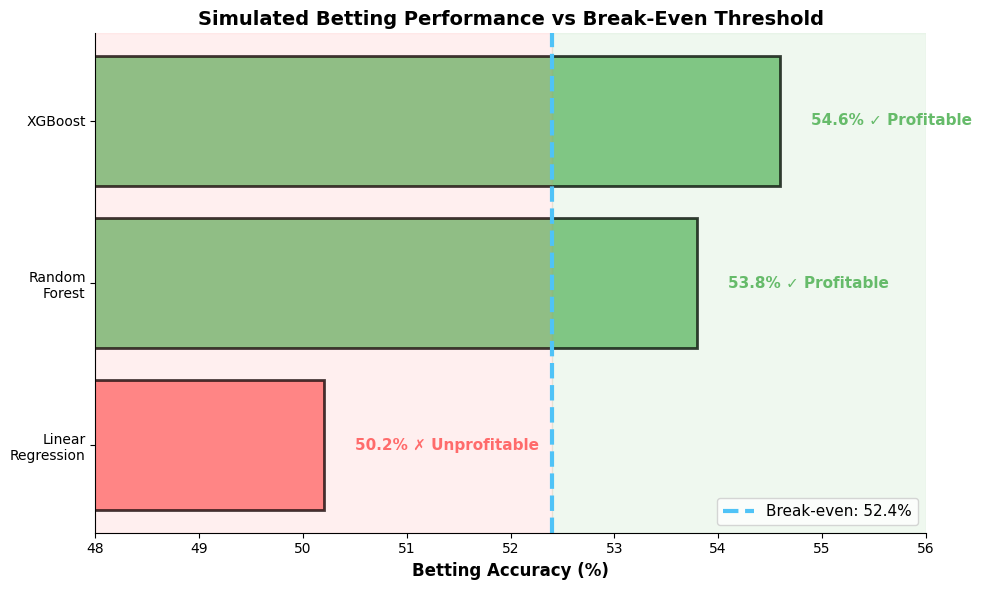

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Betting results data (from your paper)
models_betting = ['Linear\nRegression', 'Random\nForest', 'XGBoost']
accuracies = [50.2, 53.8, 54.6]
breakeven = 52.4

fig, ax = plt.subplots(figsize=(10, 6))

# Color bars based on profitability
colors_bet = ['#ff6b6b' if acc < breakeven else '#66bb6a' for acc in accuracies]
bars = ax.barh(models_betting, accuracies, color=colors_bet, alpha=0.8,
               edgecolor='black', linewidth=2)

# Add break-even line
ax.axvline(x=breakeven, color='#4fc3f7', linestyle='--', linewidth=3,
           label=f'Break-even: {breakeven}%')

# Add accuracy labels
for bar, acc in zip(bars, accuracies):
    status = '✓ Profitable' if acc > breakeven else '✗ Unprofitable'
    color_text = '#66bb6a' if acc > breakeven else '#ff6b6b'
    ax.text(acc + 0.3, bar.get_y() + bar.get_height()/2,
            f'{acc}% {status}',
            va='center', fontsize=11, fontweight='bold', color=color_text)

ax.set_xlabel('Betting Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_title('Simulated Betting Performance vs Break-Even Threshold',
             fontsize=14, fontweight='bold')
ax.set_xlim(48, 56)
ax.legend(fontsize=11, loc='lower right')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add shaded regions
ax.axvspan(48, breakeven, alpha=0.1, color='#ff6b6b')
ax.axvspan(breakeven, 56, alpha=0.1, color='#66bb6a')

plt.tight_layout()
plt.savefig('betting_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

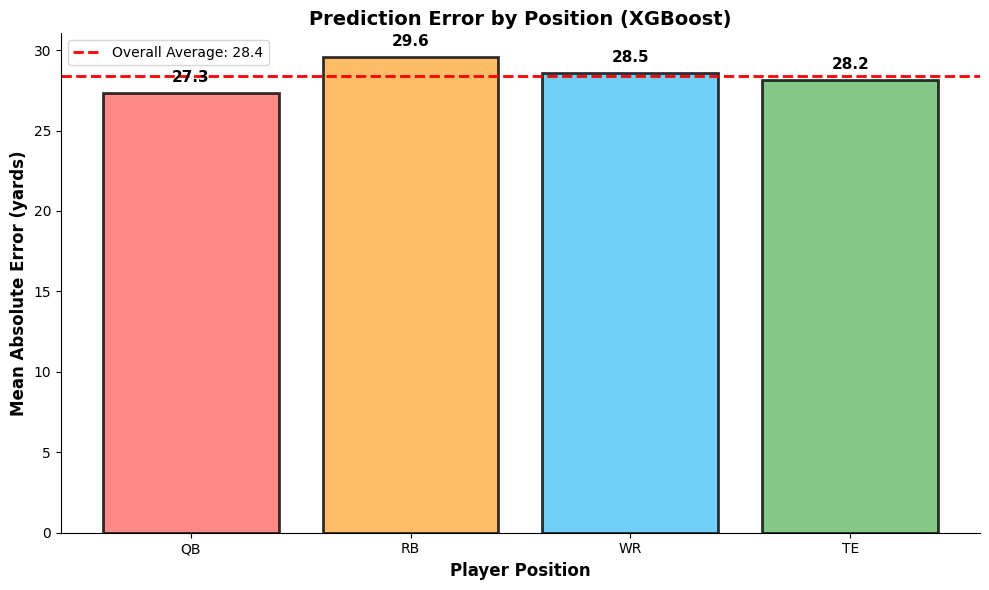

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Extract necessary data from the predictor object
X_test = predictor.X_test
y_test = predictor.y_test
xgb_predictions = predictor.results['XGBoost']['test_pred']

# The original 'position' column was one-hot encoded into 'pos_QB', 'pos_RB', etc.
# We reconstruct the position labels for analysis
pos_cols = [col for col in X_test.columns if col.startswith('pos_')]
if pos_cols:
    # Get the position from the dummy columns
    reconstructed_pos = X_test[pos_cols].idxmax(axis=1).str.replace('pos_', '')

    positions = ['QB', 'RB', 'WR', 'TE']
    mae_by_position = []

    for pos in positions:
        pos_mask = reconstructed_pos == pos
        pos_predictions = xgb_predictions[pos_mask]
        pos_actual = y_test[pos_mask]
        if len(pos_actual) > 0:
            pos_mae = np.mean(np.abs(pos_actual - pos_predictions))
        else:
            pos_mae = 0
        mae_by_position.append(pos_mae)

    fig, ax = plt.subplots(figsize=(10, 6))
    colors_pos = ['#ff6b6b', '#ffab40', '#4fc3f7', '#66bb6a']
    bars = ax.bar(positions, mae_by_position, color=colors_pos, alpha=0.8,
                  edgecolor='black', linewidth=2)

    ax.set_ylabel('Mean Absolute Error (yards)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Player Position', fontsize=12, fontweight='bold')
    ax.set_title('Prediction Error by Position (XGBoost)', fontsize=14, fontweight='bold')

    avg_mae = np.mean(mae_by_position)
    ax.axhline(y=avg_mae, color='red', linestyle='--', linewidth=2,
               label=f'Overall Average: {avg_mae:.1f}')

    for bar, val in zip(bars, mae_by_position):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{val:.1f}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

    ax.legend(fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()
else:
    print("Could not find encoded position columns in X_test.")

## 11. Next Steps & Extensions

**Potential Improvements:**
1. Integrate real NFL data from API sources
2. Add player-specific features (route participation, target share)
3. Implement LSTM for time-series patterns
4. Add confidence intervals to predictions
5. Create ensemble models combining RF + XGBoost
6. Incorporate injury reports and news sentiment
7. Position-specific models (separate QB, RB, WR, TE)

**For Production Use:**
- Cross-validation for robustness
- Hyperparameter optimization (GridSearchCV)
- Real-time prediction pipeline
- Betting bankroll management system
- Model retraining schedule

In [ ]:
# Save results to CSV for further analysis
eval_results.to_csv('/content/model_evaluation.csv', index=False)
betting_results.to_csv('/content/betting_simulation.csv', index=False)
importance_df.to_csv('/content/feature_importance.csv', index=False)

print("✓ Results exported to CSV files:")
print("  - model_evaluation.csv")
print("  - betting_simulation.csv")
print("  - feature_importance.csv")

✓ Results exported to CSV files:
  - model_evaluation.csv
  - betting_simulation.csv
  - feature_importance.csv
